## **Modelagem: Rede Neural**

Neste notebook vamos construir e testar um modelo de rede neural com Keras para prever os funcionários que pedirão demissão voluntária. Nosso objetivo é conseguir detectar o máximo possível de funcionários "em risco" de demissão voluntária, bem como descobrir os fatores potencialmente responsáveis por essas demissões.

O processo de modelagem seguirá as seguintes etapas:

- **Carregamento e exploração dos dados**: vamos carregar os dados de treinamento e entender sua estrutura.

- **Pré-processamento**: vamos aplicar transformações necessárias aos dados para alimentar a rede neural.

- **Construção do modelo**: vamos definir a arquitetura da rede neural usando Keras.

- **Treinamento**: vamos treinar o modelo com early stopping para evitar overfitting.

- **Avaliação**: vamos avaliar o desempenho do modelo usando métricas como acurácia, precisão, recall e f1-score.

- **Teste**: vamos testar o modelo no conjunto de teste para estabelecer seu desempenho final.

### 📚 Importação das bibliotecas

Nesta seção importamos todas as bibliotecas necessárias para o projeto, organizadas por finalidade:

- **Bibliotecas base**:  
  `numpy`, `pandas`, `matplotlib`, `joblib` — utilizadas para manipulação de dados, análise e visualização.

- **Redes neurais (TensorFlow/Keras)**:  
  Importamos o `tensorflow` e seus módulos (`keras`, `layers`, `callbacks`) para construção, treinamento e monitoramento da rede neural.

- **Pré-processamento (scikit-learn)**:  
  Inclui ferramentas como `ColumnTransformer`, `Pipeline`, `SimpleImputer`, `KNNImputer`, `OneHotEncoder`, `OrdinalEncoder`, `StandardScaler` e `TargetEncoder` para preparar os dados.

- **Validação e busca (scikit-learn)**:  
  Usamos `train_test_split` para dividir treino/validação e `RandomizedSearchCV` para ajuste de hiperparâmetros.

Essa organização facilita a leitura e manutenção do código, destacando claramente as funções de cada conjunto de bibliotecas.


In [1]:
### libs ###
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# Para redes neurais
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau


### Pré-processamento ###
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler,TargetEncoder
from sklearn.pipeline import Pipeline

### Validação e busca ###
from sklearn.model_selection import RandomizedSearchCV

from sklearn.model_selection import train_test_split

## Carregamento dos Dados de Treino

Neste passo, os arquivos de treino previamente salvos em **CSV** são carregados para o ambiente:

1. **`X_train.csv`**  
   - Contém as variáveis preditoras (features) já separadas para treino.  
   - É lido em um DataFrame `X_train`.

2. **`y_train.csv`**  
   - Contém apenas a variável alvo (target), indicando o desfecho que se deseja prever.  
   - É lido em um DataFrame `y_train`.

---

👉 Esses arquivos foram gerados anteriormente no processo de preparação dos dados (divisão treino/teste) e agora serão usados como entrada para o pipeline de modelagem.


In [2]:
### dados ###
X_train = pd.read_csv("X_train.csv")
y_train = pd.read_csv("y_train.csv").values.ravel()  # Converte para array 1D

### 🗂️ Definição dos grupos de variáveis

Antes de aplicar o pré-processamento, organizamos as variáveis do dataset em grupos, de acordo com sua natureza.  
Essa separação é importante porque cada tipo de variável requer um tratamento específico (imputação, codificação, escalonamento etc.).

- **Binárias (`binarias`)**: variáveis categóricas com apenas duas categorias possíveis (ex.: `catl_sexo`, `catl_doenca_cronica`).
- **Numéricas (`numericas`)**: variáveis quantitativas contínuas ou discretas (ex.: `num_idade`, `num_consultas`).
- **Ordinais (`ordinais`)**: variáveis categóricas que possuem uma ordem natural entre os valores (ex.: `ord_saude`, `ord_remedio_semana`).
- **Categóricas (`categoricas`)**: variáveis qualitativas sem ordem definida (ex.: `catl_cor_raca`, `cath_fonte_de_agua`).
- **Alta cardinalidade (`alta_cardinalidade`)**: variáveis categóricas com grande número de categorias distintas, que serão tratadas com `TargetEncoder` (ex.: `cath_trabalho`, `cath_destino_do_esgoto`).

Esses grupos são usados no `ColumnTransformer` para garantir que cada tipo de dado receba o pré-processamento adequado.


In [3]:
# 1) Grupos de variáveis
tipos_variaveis1 = {
    "binarias": [
        "catl_sexo","catl_doenca_cronica","catl_animais","catl_homeopatia",
        "catl_internacao","catl_quimicos","catl_ruidos","catl_sol",
        "catl_material_biologico","catl_plano_saude","catl_medicamentos",
        "catl_plantas_medicinais","catl_deixar_atividades","catl_servico_saude",
        "catl_recebeu_atendimento","catl_lixo","catl_poeira_mineral",
        "catl_plano_consultas","catl_plano_exames","catl_plano_internacoes",
        "catl_crise_asma","catl_remedio_asma","catl_aerossol_asma",
        "catl_cigarro","catl_pagou_remedio","catl_domicilio_cadastrado"
    ],

    "numericas": [
        "num_idade","catl_cachoros","catl_gatos",
        "num_idade_diagnostico","num_consultas"
    ],

    "ordinais": [
        "ord_saude","ord_limita_asma","ord_agente_saude",
        "ord_nivel_plano","ord_remedio_semana","ord_remedio_sus",
        "ord_farmacia_popular"
    ],

    "categoricas": [
        "catl_cor_raca","catl_tipo_de_area","catl_tipo_de_domicilio",
        "cath_material_parede","cath_fonte_de_agua",
        "catl_destino_do_lixo","catl_atividade","cath_estado_agua",
        "cath_local_atendimento"
    ],

    "alta_cardinalidade": [
        "cath_destino_do_esgoto","cath_trabalho"
    ]
}


### ⚙️ Definição dos pipelines de pré-processamento

Nesta etapa, configuramos pipelines específicos para cada tipo de variável, garantindo que cada grupo receba o tratamento adequado:

- **Numéricas (`num_pipe`)**:  
  Aplicamos imputação com `KNNImputer` e padronização com `StandardScaler`.

- **Ordinais (`ord_pipe`)**:  
  Usamos `SimpleImputer` para valores faltantes e `OrdinalEncoder` para manter a ordem natural das categorias.

- **Binárias (`bin_pipe`)**:  
  Tratadas com `SimpleImputer` seguido de `OneHotEncoder` (com `drop="if_binary"`).

- **Categóricas (`cat_pipe`)**:  
  Recebem `SimpleImputer` e `OneHotEncoder`, preservando a representação esparsa quando útil.

- **Alta cardinalidade (`high_card_pipe`)**:  
  Usamos `TargetEncoder` após a imputação para lidar melhor com muitas categorias.

Todos esses pipelines são reunidos no **`ColumnTransformer (pre)`**, que aplica automaticamente cada transformação às variáveis correspondentes em `tipos_variaveis1`.  
Dessa forma, garantimos que o dataset seja processado de forma consistente antes de treinar o modelo.


In [4]:
# OneHot compatível (usa esparso quando fizer sentido)
ohe_kwargs = dict(handle_unknown="ignore", dtype=np.float32)
try:
    OHE_BIN = OneHotEncoder(drop="if_binary", sparse_output=True, **ohe_kwargs)
    OHE_CAT = OneHotEncoder(sparse_output=True, **ohe_kwargs)
except TypeError:  # sklearn<1.2
    OHE_BIN = OneHotEncoder(drop="if_binary", sparse=True, **ohe_kwargs)
    OHE_CAT = OneHotEncoder(sparse=True, **ohe_kwargs)

# ---- Pipelines ----
num_pipe = Pipeline([
    ("imputer", KNNImputer(n_neighbors=10)),
    ("scaler", StandardScaler())
])

ord_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("enc", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

bin_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OHE_BIN)
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OHE_CAT)
])

high_card_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("target", TargetEncoder())
])



pre = ColumnTransformer(
    transformers=[
        ("numeric",     num_pipe, tipos_variaveis1["numericas"]),
        ("ordinal",     ord_pipe, tipos_variaveis1["ordinais"]),
        ("binary",      bin_pipe, tipos_variaveis1["binarias"]),
        ("categorical", cat_pipe, tipos_variaveis1["categoricas"]),
        ("high_card",   high_card_pipe, tipos_variaveis1["alta_cardinalidade"]),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
    # IMPORTANTE: não force esparso aqui; deixe o CT decidir
    # sparse_threshold=0.3  # (padrão). Pode omitir.
)

## **Modelo de Rede Neural**

Vamos construir uma rede neural com Keras. A arquitetura será composta por:

- Camadas densas com ativação ReLU
- Camadas de dropout para evitar overfitting
- Camada de saída com ativação sigmoid para classificação binária

Usaremos o otimizador Adam e a função de perda binary_crossentropy.

### 🔄 Pré-processamento dos dados

Nesta etapa aplicamos o `ColumnTransformer (pre)` aos dados de treino.  
Esse transformador já inclui todos os **imputadores**, **escalonadores** e **codificadores** definidos nas pipelines (`num_pipe`, `ord_pipe`, `bin_pipe`, `cat_pipe` e `high_card_pipe`).  

Assim, ao chamar `pre.fit_transform(X_train, y_train)`, todos os passos de tratamento são aplicados de uma vez, sem necessidade de rodar o `imputer` separadamente.  

O resultado será a matriz `X_train_processed`, pronta para ser utilizada no treinamento do modelo de rede neural.


In [5]:
# Aplicando o pré-processamento aos dados de treino
X_train_processed = pre.fit_transform(X_train, y_train)

print("Formato dos dados processados X_train:", X_train_processed.shape)


Formato dos dados processados X_train: (72676, 101)


### ✂️ Divisão em treino e validação

Após o pré-processamento, dividimos os dados em **treino** e **validação** utilizando `train_test_split`.  
- Usamos `test_size=0.2`, ou seja, **20% dos dados** foram separados para validação.  
- O parâmetro `stratify=y_train` garante que a proporção entre as classes (balanceamento) seja mantida nas duas amostras.  
- Também fixamos `random_state=42` para garantir **reprodutibilidade** dos resultados.  

Com isso, teremos:
- `X_train_final` e `y_train_final`: dados de treino  
- `X_val` e `y_val`: dados de validação


In [6]:
# Dividindo os dados em treino e validação
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_processed, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print("Formato dos dados de treino:", X_train_final.shape)
print("Formato dos dados de validação:", X_val.shape)

Formato dos dados de treino: (58140, 101)
Formato dos dados de validação: (14536, 101)


### 🧠 Definição do Modelo de Rede Neural

A seguir construímos uma rede neural utilizando **Keras (TensorFlow)**, projetada para classificação binária.  
A arquitetura foi desenhada para equilibrar **capacidade de aprendizado** e **regularização**, evitando overfitting:

- **Camada de entrada + 1ª oculta (256 neurônios)**  
  - `Dense(256)` para capturar relações complexas  
  - `BatchNormalization` para estabilizar os gradientes e acelerar o treino  
  - `ReLU` como função de ativação  
  - `Dropout(0.3)` para regularização  

- **2ª camada oculta (128 neurônios)**  
  - `Dense(128)` + `BatchNormalization` + `ReLU`  
  - `Dropout(0.2)`  

- **3ª camada oculta (64 neurônios)**  
  - `Dense(64)` + `BatchNormalization` + `ReLU`  
  - `Dropout(0.1)`  

- **4ª camada oculta (32 neurônios)**  
  - `Dense(32)` + `BatchNormalization` + `ReLU`  

- **Camada de saída**  
  - `Dense(1, activation='sigmoid')` → saída entre 0 e 1 para classificação binária  

---

### ⚙️ Hiperparâmetros e Treinamento
- **Otimizador**: `Adam(learning_rate=0.001)`  
- **Função de perda**: `binary_crossentropy` (adequada para problemas binários)  
- **Métricas**:  
  - `accuracy`: métrica simples para referência  
  - `AUC`: mais robusta em datasets desbalanceados  

---


In [8]:
model = keras.Sequential([
        # Camada de entrada e primeira camada oculta mais larga
        layers.Dense(256),
        layers.BatchNormalization(), # Ajuda a estabilizar e acelerar o treinamento
        layers.Activation('relu'),   # Ativação após BatchNormalization
        layers.Dropout(0.4),         # Aumentei um pouco o dropout devido à maior capacidade

        # Segunda camada oculta mais larga
        layers.Dense(128),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),

        # Segunda camada oculta mais larga
        layers.Dense(64),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.1),

        # Terceira camada oculta (mantida ou ligeiramente aumentada)
        layers.Dense(32),
        layers.BatchNormalization(),
        layers.Activation('relu'),

        # Camada de saída
        layers.Dense(1, activation='sigmoid') # Para classificação binária
    ])
    
    # Otimizador Adam com taxa de aprendizado configurável
optimizer = keras.optimizers.Adam(learning_rate=0.0001)
    
model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')] # Adicionando AUC como métrica
    )
    

# Criando o modelo
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_4 (Activation)            │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_5 (Activation)            │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_6 (Activation)            │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_7 (Activation)            │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### ⚡ Treinamento do modelo com callbacks

Para treinar a rede neural, utilizamos dois **callbacks principais** em conjunto com o método `fit`:

---

#### 🛑 EarlyStopping
- **Monitor:** `val_auc` (métrica mais confiável em datasets desbalanceados).  
- **Patience:** `20` → o treinamento será interrompido caso a métrica não melhore após 20 épocas consecutivas.  
- **Mode:** `max` → porque quanto maior a AUC, melhor.  
- **Restore Best Weights:** garante que ao final o modelo recupere os pesos da **melhor época** de validação, e não da última.

---

#### 📉 ReduceLROnPlateau
- **Monitor:** `val_auc`.  
- **Factor:** `0.5` → reduz a *learning rate* pela metade quando necessário.  
- **Patience:** `10` → espera 10 épocas sem melhora antes de reduzir a taxa de aprendizado.  
- **Mode:** `max`.  
- **min_lr:** `1e-6` → define um limite mínimo para a taxa de aprendizado.  
- **Verbose=1:** exibe mensagens informando quando a redução ocorre.

Esse callback ajuda a refinar o aprendizado quando o modelo “empaca”, diminuindo o tamanho dos passos do otimizador.

---

#### ⚙️ Configuração do `fit`
- **epochs=1000** → número máximo de épocas (o EarlyStopping vai parar antes se não houver melhora).  
- **batch_size=32** → tamanho do lote usado para cada atualização dos pesos.  
- **validation_data=(X_val, y_val)** → conjunto de validação para monitorar desempenho.  
- **callbacks=[early_stopping, reduce_lr]** → aplica os callbacks definidos.  
- **verbose=1** → mostra o progresso do treino em cada época.

---

➡️ Com essa configuração, o modelo treina até atingir o melhor desempenho possível em validação, economizando tempo e reduzindo risco de overfitting.


In [9]:
early_stopping = EarlyStopping(
    monitor='val_auc',          # métrica mais confiável em dados desbalanceados
    patience=15,
    mode='max',
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_auc',
    factor=0.5,     # reduz a LR pela metade
    patience=15,    # espera 10 épocas sem melhora antes de reduzir
    mode='max',
    min_lr=1e-6,
)

history = model.fit(
    X_train_final, y_train_final,
    epochs=1000,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)


Epoch 1/1000
909/909 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.6083 - auc: 0.5547 - loss: 0.6688 - val_accuracy: 0.9548 - val_auc: 0.7720 - val_loss: 0.3393 - learning_rate: 1.0000e-04
Epoch 2/1000
909/909 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9490 - auc: 0.7105 - loss: 0.2835 - val_accuracy: 0.9649 - val_auc: 0.8576 - val_loss: 0.1671 - learning_rate: 1.0000e-04
Epoch 3/1000
909/909 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9624 - auc: 0.8078 - loss: 0.1728 - val_accuracy: 0.9685 - val_auc: 0.9057 - val_loss: 0.1196 - learning_rate: 1.0000e-04
Epoch 4/1000
909/909 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9658 - auc: 0.8643 - loss: 0.1347 - val_accuracy: 0.9692 - val_auc: 0.9297 - val_loss: 0.1045 - learning_rate: 1.0000e-04
Epoch 5/1000
909/909 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9673 - auc: 0.8982 - loss: 0.1172 - val_accuracy: 0.9709 - val_auc: 0.9411 - val_loss: 0.0939 - learning_rate: 1.0000e-04
Epoch 6/1000
909/909 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/

### 📊 Visualização das curvas de aprendizado

Após o treinamento, é importante analisar as métricas para entender o comportamento da rede neural.  
Aqui utilizamos os dados do objeto `history`, que armazena as métricas de cada época do treinamento.

---

#### 🔴 Curva de Perda (Loss)
- **Treino (`loss`)**: mostra a evolução da função de perda no conjunto de treino.  
- **Validação (`val_loss`)**: indica como o modelo está se generalizando para dados não vistos.  

➡️ Idealmente, ambas as curvas devem **diminuir** ao longo das épocas.  
Se a `val_loss` começar a subir enquanto a `loss` continua caindo, isso indica **overfitting**.

---

#### 🔵 Curva de Acurácia
- **Treino (`accuracy`)**: mede a proporção de acertos no conjunto de treino.  
- **Validação (`val_accuracy`)**: mede a proporção de acertos no conjunto de validação.  

➡️ As curvas devem crescer juntas até estabilizar.  
Se a acurácia de treino continuar subindo, mas a de validação parar ou cair, pode ser sinal de **overfitting**.

---

📌 Essas visualizações ajudam a decidir:
- Se o número de épocas foi adequado.  
- Se o modelo está sofrendo de overfitting ou underfitting.  
- Se é necessário ajustar regularização, dropout, ou taxa de aprendizado.


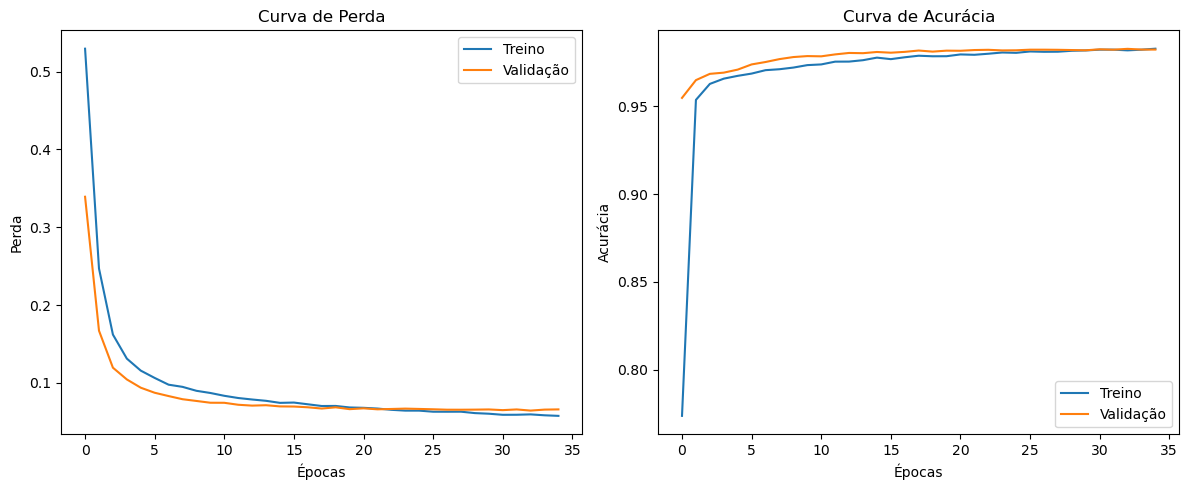

In [10]:
# Visualizando as curvas de aprendizado
plt.figure(figsize=(12, 5))

# Gráfico de perda
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Curva de Perda')
plt.xlabel('Épocas')
plt.ylabel('Perda')
plt.legend()

# Gráfico de acurácia
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.title('Curva de Acurácia')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()

plt.tight_layout()
plt.show()

## **Avaliação do modelo no conjunto completo de treinamento**

### 🎯 Classificador baseline

Antes de avaliar o desempenho de modelos mais sofisticados (como redes neurais), é importante ter um **ponto de referência**.  
Para isso, utilizamos o `DummyClassifier` do scikit-learn, que cria previsões de forma **aleatória ou simples**, sem aprendizado real.

- **Estratégia utilizada:** `stratified`  
  - Gera previsões mantendo a mesma proporção de classes do conjunto de treino.  
- **Objetivo:** fornecer uma **baseline mínima de desempenho**.  
  - Se o modelo de rede neural não superar esse baseline, significa que não está aprendendo nada além do acaso.

Com isso, garantimos uma comparação justa entre o modelo treinado e um classificador puramente aleatório.


In [11]:
# classificador baseline aleatório
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy="stratified", random_state=42)

dummy.fit(X_train_processed, y_train)

DummyClassifier(random_state=42, strategy='stratified')

### 📊 Comparação com o modelo baseline

Após treinar a rede neural, é essencial compará-la com o classificador baseline (`DummyClassifier`).  
Essa comparação mostra se a rede realmente está aprendendo ou se seu desempenho é equivalente ao acaso.

- **Predições da rede neural**:  
  - Utilizamos `model.predict` para obter probabilidades.  
  - Convertidas em rótulos binários (`0` ou `1`) aplicando um limiar de `0.5`.

- **Métricas de acurácia**:  
  - `acc_dummy`: acurácia do classificador aleatório.  
  - `acc_modelo`: acurácia da rede neural.  

- **Interpretação**:  
  - Se `acc_modelo > acc_dummy`, significa que a rede neural está capturando padrões reais nos dados.  
  - A diferença `acc_modelo - acc_dummy` indica o ganho percentual em relação ao baseline.

Essa etapa garante que nosso modelo supera uma referência mínima, validando o esforço de utilizar redes neurais.


In [12]:
# Comparando com o modelo baseline
from sklearn.metrics import accuracy_score

y_pred_proba = model.predict(X_train_processed)
y_pred = (y_pred_proba > 0.4).astype(int)

acc_dummy = accuracy_score(y_train, dummy.predict(X_train_processed))
acc_modelo = accuracy_score(y_train, y_pred.reshape(len(y_pred)))

print(f"O modelo dummy obteve acurácia de {acc_dummy:.1%}")
print(f"O modelo de rede neural obteve acurácia de {acc_modelo:.1%}")
print(f"Isso significa que a rede neural trouxe um aumento de acurácia de {acc_modelo - acc_dummy:.1%}")

2272/2272 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
O modelo dummy obteve acurácia de 90.8%
O modelo de rede neural obteve acurácia de 98.5%
Isso significa que a rede neural trouxe um aumento de acurácia de 7.7%


### 📈 Curva ROC – Rede Neural vs. Baseline

A Curva ROC (Receiver Operating Characteristic) é uma ferramenta fundamental para avaliar classificadores binários, especialmente em datasets **desbalanceados**.  
Ela mostra a relação entre:

- **Eixo X (FPR – False Positive Rate)**: taxa de falsos positivos.  
- **Eixo Y (TPR – True Positive Rate)**: taxa de verdadeiros positivos (ou sensibilidade).  

---

#### 🔎 O que foi feito
1. **Rede Neural**  
   - Calculamos `fpr` e `tpr` com `roc_curve`.  
   - Plotamos a curva em vermelho, com o valor da AUC no rótulo.  

2. **DummyClassifier (baseline)**  
   - Curva calculada da mesma forma.  
   - Plotada em azul, com AUC de referência.  

3. **Configurações do gráfico**  
   - Limites de eixos ajustados para `[0.0, 1.0]`.  
   - Títulos e rótulos configurados para clareza.  
   - Legenda exibida no canto inferior direito.

---

#### 📌 Interpretação
- **AUC (Área sob a curva)** é uma métrica robusta para problemas desbalanceados:  
  - `AUC = 0.5` → modelo aleatório.  
  - `AUC > 0.7` → modelo aceitável.  
  - `AUC > 0.8` → bom modelo.  
  - `AUC > 0.9` → excelente desempenho.  

Se a curva da **rede neural** fica consistentemente **acima** da curva do **DummyClassifier**, isso confirma que o modelo está aprendendo padrões reais e supera a baseline aleatória.


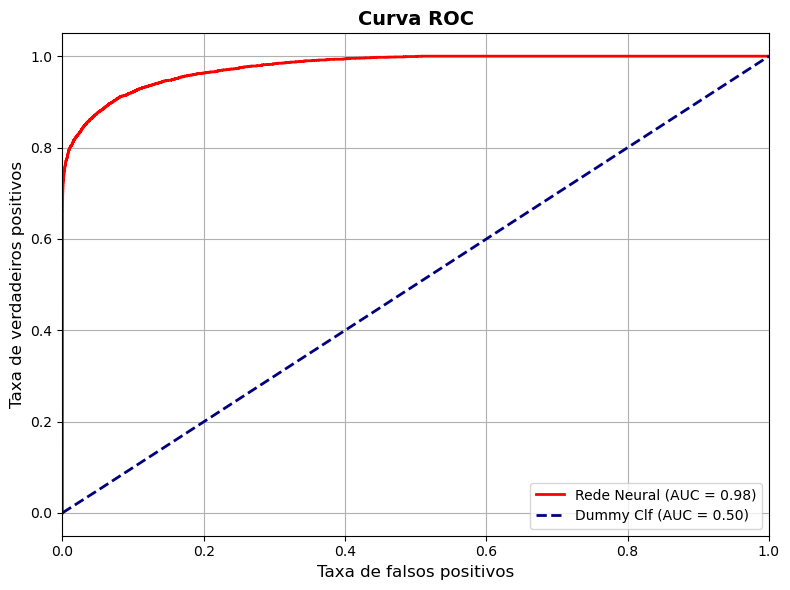

In [13]:
# Curva ROC
from sklearn.metrics import roc_curve, auc
fpr_d, tpr_d, thresholds_d = roc_curve(y_train, dummy.predict_proba(X_train_processed)[:, 1])
fpr, tpr, thresholds = roc_curve(y_train, y_pred_proba)

# Gráfico
plt.figure(figsize=(8, 6))

# Plot da curva ROC da Rede Neural
plt.plot(fpr, tpr,
         color='red', 
         linewidth=2,
         label=f'Rede Neural (AUC = {auc(fpr, tpr):.2f})')

# Plot da curva ROC do Dummy Classifier
plt.plot(fpr_d, tpr_d,
         color='navy', 
         linestyle='--',
         linewidth=2,
         label=f'Dummy Clf (AUC = {auc(fpr_d, tpr_d):.2f})')

# Configurações do gráfico
plt.xlim([0.0, 1.0])
plt.ylim([-0.05, 1.05])
plt.xlabel('Taxa de falsos positivos', fontsize=12)
plt.ylabel('Taxa de verdadeiros positivos', fontsize=12)
plt.title('Curva ROC', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()

### 📊 Precisão, Recall e F1-score

Além da acurácia, usamos três métricas importantes para dados desbalanceados:

- **Precisão (Precision):** indica a proporção de predições positivas que realmente são positivas (evita falsos positivos).  
- **Recall (Sensibilidade):** mede a proporção de positivos detectados corretamente (evita falsos negativos).  
- **F1-score:** média harmônica entre precisão e recall, equilibrando as duas métricas.

Aqui comparamos esses valores entre o **DummyClassifier (baseline)** e a **rede neural**, mostrando se o modelo de fato supera o desempenho aleatório.


In [14]:
# Recall, precisão, f1_score
from sklearn.metrics import precision_score, recall_score, f1_score

prec_dummy = precision_score(y_train, dummy.predict(X_train_processed))
prec_modelo = precision_score(y_train, y_pred)

rec_dummy = recall_score(y_train, dummy.predict(X_train_processed))
rec_modelo = recall_score(y_train, y_pred)

f1_dummy = f1_score(y_train, dummy.predict(X_train_processed))
f1_modelo = f1_score(y_train, y_pred)

print(f"O modelo dummy obteve precisão de {prec_dummy:.1%}, recall de {rec_dummy:.1%} e f1 de {f1_dummy:.1%}")
print(f"O modelo de rede neural obteve precisão de {prec_modelo:.1%}, recall de {rec_modelo:.1%} e f1 de {f1_modelo:.1%}")

O modelo dummy obteve precisão de 4.8%, recall de 4.7% e f1 de 4.8%
O modelo de rede neural obteve precisão de 98.4%, recall de 70.2% e f1 de 82.0%


## **Endpoint**

Vamos salvar o melhor modelo e conjunto de encoders. 

## Salvando modelo e preparando dados de teste

Nesta etapa:
1. Salvamos o modelo treinado no formato Keras/HDF5.
2. Carregamos os conjuntos de teste (`X_test.csv` e `y_test.csv`).
3. Aplicamos o pré-processamento definido (`pre.transform`) para deixar os dados no formato aceito pela rede neural.
4. Exportamos o conjunto de teste já transformado para um novo arquivo (`X_test_keras.csv`), que será usado na avaliação/predição.


In [ ]:
# Salvando o modelo treinado e os preprocessadores
model.save('modelo_rn_keras.h5')

# ajustando dados de teste para o Keras
X_test = pd.read_csv("X_test.csv")
y_test = pd.read_csv("y_test.csv")["num_asma"].values

X_test_keras = pre.transform(X_test)


pd.DataFrame(X_test_keras).to_csv("X_test_keras.csv")